# PoC: Clasificación de Vehículos (CNN vs YOLOv8)
**Autora:** Myriam Manzanera Hernández

**Fecha:** Marzo 2026

**Contexto:** Proyecto de la asignatura Machine Learning I (Máster en Inteligencia Artificial, UTAMED).

In [8]:
# 1. IMPORTACIÓN DE LIBRERÍAS
import os
import glob
import random
import requests
from io import BytesIO
from PIL import Image
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib.ticker import MaxNLocator # Importamos la herramienta para los números enteros
%pip install ultralytics
from ultralytics import YOLO

# Configuración Global
BATCH_SIZE = 32
RANDOM_SEED = 42
IMG_SIZE = (32, 32)
tf.random.set_seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

print("Librerías importadas y entorno configurado.")

Librerías importadas y entorno configurado.


--- Análisis del Dataset Original (CIFAR-10) ---
Número total de etiquetas (labels) originales: 10
Tamaño del set de Entrenamiento (70%): 35000
Tamaño del set de Validación (15%): 7500
Tamaño del set de Test (15%): 7500

Listado de etiquetas y su ID numérico asociado:
  ID 0: airplane
  ID 1: automobile
  ID 2: bird
  ID 3: cat
  ID 4: deer
  ID 5: dog
  ID 6: frog
  ID 7: horse
  ID 8: ship
  ID 9: truck

Dataset filtrado exitosamente. Nuevas labels mapeadas: 0-3 -> ['Airplane', 'Automobile', 'Ship', 'Truck']

--- Conteo tras el Filtrado ---
Imágenes de Train filtradas: 13973


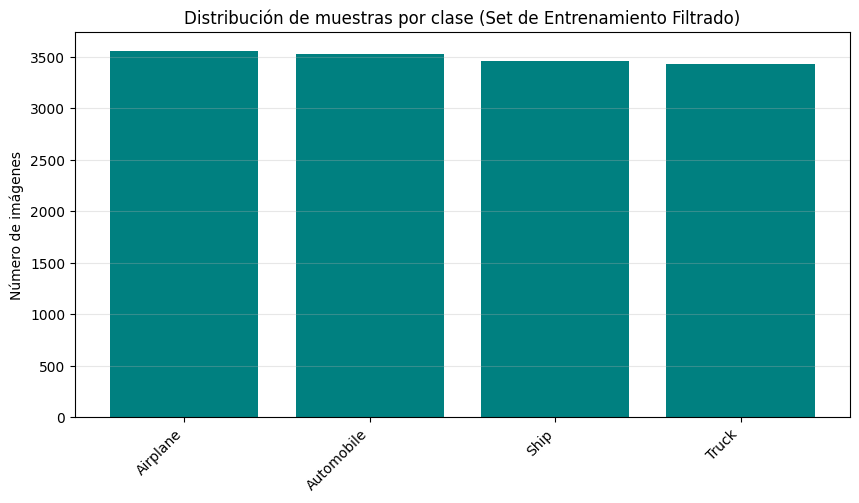

In [5]:
# 2. INGESTA, EDA Y PREPROCESAMIENTO DE DATOS
splits = ['train[:70%]', 'train[70%:85%]', 'train[85%:]']
(ds_train, ds_val, ds_test), ds_info = tfds.load(
    'cifar10', split=splits, shuffle_files=False, as_supervised=True, with_info=True
)

# --- EDA: Análisis del Dataset Original ---
label_names_original = ds_info.features['label'].names
print(f"--- Análisis del Dataset Original (CIFAR-10) ---")
print(f"Número total de etiquetas (labels) originales: {len(label_names_original)}")
print(f"Tamaño del set de Entrenamiento (70%): {len(ds_train)}")
print(f"Tamaño del set de Validación (15%): {len(ds_val)}")
print(f"Tamaño del set de Test (15%): {len(ds_test)}")

print("\nListado de etiquetas y su ID numérico asociado:")
for idx, label in enumerate(label_names_original):
    print(f"  ID {idx}: {label}")

# --- FILTRADO DE CLASES RELEVANTES ---
# Nos quedamos con: 0 (airplane), 1(automobile), 8(ship), 9(truck)
def filter_vehicles(image, label):
    return tf.reduce_any(tf.equal(label, [0, 1, 8, 9]))

def remap_labels(image, label):
    label = tf.case([
        (tf.equal(label, 0), lambda: 0),
        (tf.equal(label, 1), lambda: 1),
        (tf.equal(label, 8), lambda: 2),
        (tf.equal(label, 9), lambda: 3)
    ], default=lambda: -1)
    return image, label

def normalize_img(image, label):
    return tf.cast(image, tf.float32) / 255.0, label

# Aplicamos el filtro y remapeo
ds_train = ds_train.filter(filter_vehicles).map(remap_labels)
ds_val = ds_val.filter(filter_vehicles).map(remap_labels)
ds_test = ds_test.filter(filter_vehicles).map(remap_labels)

vehicle_labels = ['Airplane', 'Automobile', 'Ship', 'Truck']
print(f"\nDataset filtrado exitosamente. Nuevas labels mapeadas: 0-3 -> {vehicle_labels}")

# --- EDA: Distribución tras el filtrado ---
def get_labels_distribution(dataset):
    return [label.numpy() for _, label in dataset]

train_labels = get_labels_distribution(ds_train)
print(f"\n--- Conteo tras el Filtrado ---")
print(f"Imágenes de Train filtradas: {len(train_labels)}")

# Gráfico de distribución
plt.figure(figsize=(10, 5))
num_labels_filtered = len(vehicle_labels)
plt.hist(train_labels, bins=np.arange(num_labels_filtered + 1) - 0.5, rwidth=0.8, color='teal')
plt.xticks(range(num_labels_filtered), vehicle_labels, rotation=45, ha='right')
plt.title("Distribución de muestras por clase (Set de Entrenamiento Filtrado)")
plt.ylabel("Número de imágenes")
plt.grid(axis='y', alpha=0.3)
plt.show()


In [6]:
# 3. NORMALIZACIÓN Y OPTIMIZACIÓN DEL PIPELINE DE DATOS

# Definimos la función de normalización
def normalize_img(image, label):
  # Pasamos de uint8 a float32 y escalamos a [0,1]
  return tf.cast(image, tf.float32) / 255.0, label

print("Aplicando pipeline optimizado al set de entrenamiento...")
# Aplicamos el pipeline optimizado al set de entrenamiento en el siguiente orden:
# map -> cache -> shuffle -> batch -> prefetch
ds_train = ds_train.map(normalize_img, num_parallel_calls=tf.data.AUTOTUNE)
ds_train = ds_train.cache() # Guardamos en RAM para velocidad
ds_train = ds_train.shuffle(buffer_size=1000) # Mezclamos después de cachear
ds_train = ds_train.batch(BATCH_SIZE)
ds_train = ds_train.prefetch(tf.data.AUTOTUNE)

print("Aplicando pipeline a Validación...")
# Aplicamos a Validación
ds_val = ds_val.map(normalize_img, num_parallel_calls=tf.data.AUTOTUNE)
ds_val = ds_val.cache()
ds_val = ds_val.batch(BATCH_SIZE)
ds_val = ds_val.prefetch(tf.data.AUTOTUNE)

print("Aplicando pipeline a Test...")
# Aplicamos a Test
ds_test = ds_test.map(normalize_img, num_parallel_calls=tf.data.AUTOTUNE)
ds_test = ds_test.batch(BATCH_SIZE)
ds_test = ds_test.prefetch(tf.data.AUTOTUNE)

print("Pipeline de datos construido y optimizado con éxito.")

Aplicando pipeline optimizado al set de entrenamiento...
Aplicando pipeline a Validación...
Aplicando pipeline a Test...
Pipeline de datos construido y optimizado con éxito.


--- FASE A: Entrenando Modelo Base (Sin regularizar) ---
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


    437/Unknown 24s 51ms/step - accuracy: 0.5040 - loss: 1.1139

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


437/437 ━━━━━━━━━━━━━━━━━━━━ 27s 57ms/step - accuracy: 0.5042 - loss: 1.1136 - val_accuracy: 0.6663 - val_loss: 0.8123
Epoch 2/20
437/437 ━━━━━━━━━━━━━━━━━━━━ 19s 44ms/step - accuracy: 0.7069 - loss: 0.7479 - val_accuracy: 0.7602 - val_loss: 0.6123
Epoch 3/20
437/437 ━━━━━━━━━━━━━━━━━━━━ 22s 51ms/step - accuracy: 0.7759 - loss: 0.5999 - val_accuracy: 0.7894 - val_loss: 0.5717
Epoch 4/20
437/437 ━━━━━━━━━━━━━━━━━━━━ 21s 47ms/step - accuracy: 0.8041 - loss: 0.5253 - val_accuracy: 0.7801 - val_loss: 0.6056
Epoch 5/20
437/437 ━━━━━━━━━━━━━━━━━━━━ 20s 45ms/step - accuracy: 0.8272 - loss: 0.4582 - val_accuracy: 0.8080 - val_loss: 0.5200
Epoch 6/20
437/437 ━━━━━━━━━━━━━━━━━━━━ 19s 44ms/step - accuracy: 0.8518 - loss: 0.4008 - val_accuracy: 0.8149 - val_loss: 0.5050
Epoch 7/20
437/437 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.8620 - loss: 0.3637 - val_accuracy: 0.8252 - val_loss: 0.4720
Epoch 8/20
437/437 ━━━━━━━━━━━━━━━━━━━━ 19s 43ms/step - accuracy: 0.8822 - loss: 0.3223 - val_accurac

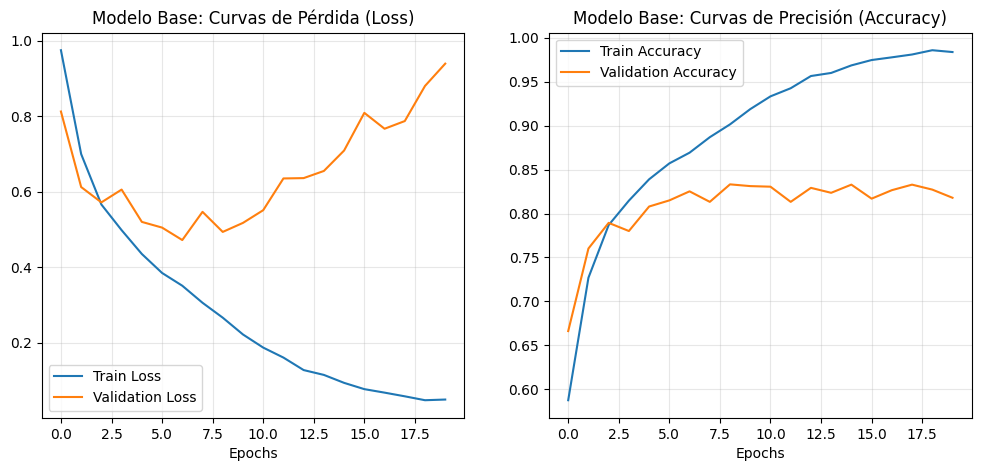


--- FASE B: Entrenando Modelo Regularizado (Dropout + Early Stopping) ---


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,172 (653.02 KB)

 Trainable params: 167,172 (653.02 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
437/437 ━━━━━━━━━━━━━━━━━━━━ 22s 46ms/step - accuracy: 0.4181 - loss: 1.2164 - val_accuracy: 0.6411 - val_loss: 0.8800
Epoch 2/20
437/437 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.6291 - loss: 0.9143 - val_accuracy: 0.7227 - val_loss: 0.7105
Epoch 3/20
437/437 ━━━━━━━━━━━━━━━━━━━━ 30s 68ms/step - accuracy: 0.6955 - loss: 0.7799 - val_accuracy: 0.7051 - val_loss: 0.6927
Epoch 4/20
437/437 ━━━━━━━━━━━━━━━━━━━━ 21s 47ms/step - accuracy: 0.7281 - loss: 0.7050 - val_accuracy: 0.7662 - val_loss: 0.5940
Epoch 5/20
437/437 ━━━━━━━━━━━━━━━━━━━━ 19s 43ms/step - accuracy: 0.7551 - loss: 0.6343 - val_accuracy: 0.7967 - val_loss: 0.5504
Epoch 6/20
437/437 ━━━━━━━━━━━━━━━━━━━━ 23s 53ms/step - accuracy: 0.7773 - loss: 0.5889 - val_accuracy: 0.7877 - val_loss: 0.5514
Epoch 7/20
437/437 ━━━━━━━━━━━━━━━━━━━━ 19s 43ms/step - accuracy: 0.8035 - loss: 0.5320 - val_accuracy: 0.7847 - val_loss: 0.5893
Epoch 8/20
437/437 ━━━━━━━━━━━━━━━━━━━━ 21s 47ms/step - accuracy: 0.8062 - loss: 0.5116 - 

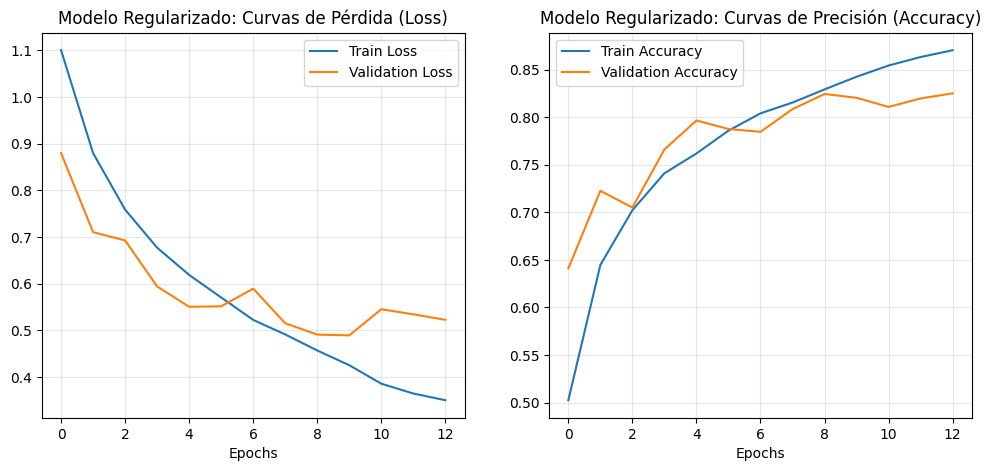

Evaluando el rendimiento final en el conjunto de Test
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.8275 - loss: 0.4779

Accuracy final en Test: 82.50%
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step


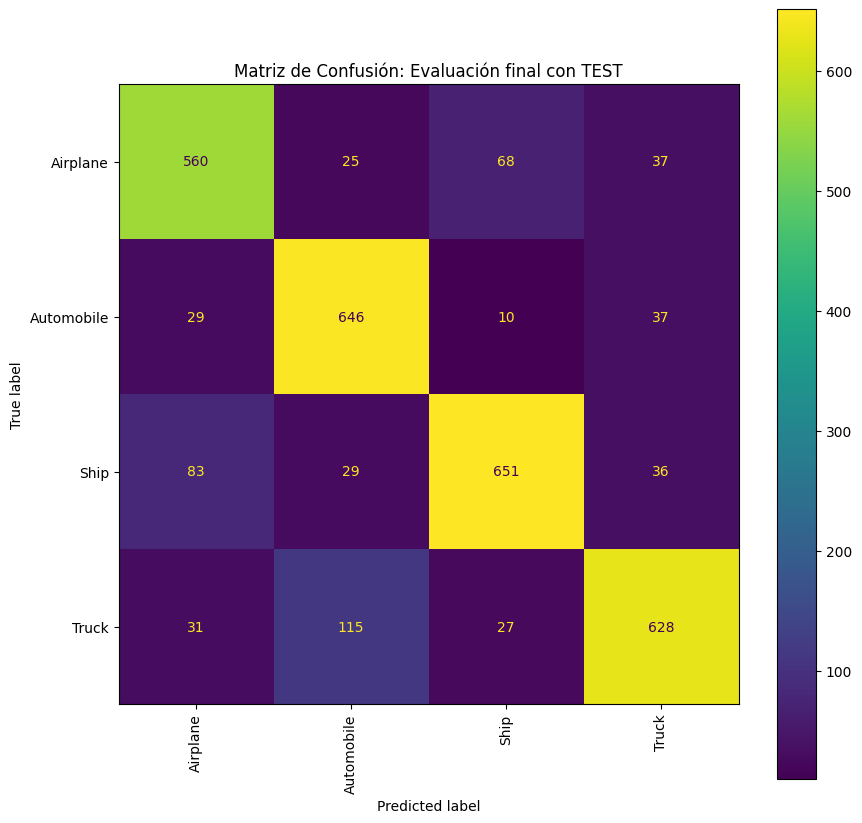

In [7]:
# =========================================================================
# 4. ENTRENAMIENTO Y COMPARATIVA DE REGULARIZACIÓN
# =========================================================================

# -------------------------------------------------------------------------
# FASE A: MODELO BASE (Sin Regularización para evidenciar el Overfitting)
# -------------------------------------------------------------------------
print("--- FASE A: Entrenando Modelo Base (Sin regularizar) ---")
model_base = models.Sequential([
    # Capa 1: Extracción de bordes y texturas simples
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    # Capa 2: Patrones complejos
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Capa 3: Aplanado
    layers.Flatten(),

    # Clasificación (MLP)
    layers.Dense(64, activation='relu'),

    # Capa de salida
    layers.Dense(num_labels_filtered, activation='softmax')
])

model_base.compile(optimizer='Adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Entrenamos a 20 épocas
history_base = model_base.fit(
    ds_train,
    validation_data=ds_val,
    epochs=20,
    verbose=1)

# Gráficas del Modelo Base
plt.figure(figsize=(12,5))

# Gráfica de Pérdida (Loss)
plt.subplot(1,2,1)
plt.plot(history_base.history['loss'], label='Train Loss')
plt.plot(history_base.history['val_loss'], label='Validation Loss')
plt.title('Modelo Base: Curvas de Pérdida (Loss)')
plt.xlabel('Epochs')
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.legend()
plt.grid(True, alpha=0.3)

# Gráfica de Precisión (Accuracy)
plt.subplot(1,2,2)
plt.plot(history_base.history['accuracy'], label='Train Accuracy')
plt.plot(history_base.history['val_accuracy'], label='Validation Accuracy')
plt.title('Modelo Base: Curvas de Precisión (Accuracy)')
plt.xlabel('Epochs')
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# -------------------------------------------------------------------------
# FASE B: MODELO REGULARIZADO
# -------------------------------------------------------------------------
print("\n--- FASE B: Entrenando Modelo Regularizado (Dropout + Early Stopping) ---")

# #5. Definimos el modelo
model = models.Sequential([
    # Capa 1: Extracción de bordes y texturas simples
    layers.Conv2D(32, (3,3), activation = 'relu', input_shape = (32,32,3)),
    layers.MaxPooling2D((2,2)),

    # Capa 2: Patrones complejos.
    layers.Conv2D(64, (3,3), activation = 'relu'),
    layers.MaxPooling2D((2,2)),

    # Capa 3: Aplanado
    layers.Flatten(),

    # Clasificación (MLP)
    layers.Dense(64, activation = 'relu'),

    # Regularización por Dropout (apagamos el 50% de las neuronas para evitar el overfitting)
    layers.Dropout(0.5),

    #Capa de salida
    layers.Dense(num_labels_filtered, activation = 'softmax')
])

model.summary()

# #6. Entrenamiento del modelo con Early Stopping
model.compile(
    optimizer='Adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#Definimos el callback de Early Stopping
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Dataset de validación
history_reg = model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=20,
    callbacks=[early_stop],
    verbose=1
)

# #7. Visualización de las curvas de aprendizaje
plt.figure(figsize=(12,5))

# Gráfica de Pérdida (Loss)
plt.subplot(1,2,1)
plt.plot(history_reg.history['loss'], label='Train Loss')
plt.plot(history_reg.history['val_loss'], label='Validation Loss')
plt.title('Modelo Regularizado: Curvas de Pérdida (Loss)')
plt.xlabel('Epochs')
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.legend()
plt.grid(True, alpha=0.3)

# Gráfica de Precisión (Accuracy)
plt.subplot(1,2,2)
plt.plot(history_reg.history['accuracy'], label='Train Accuracy')
plt.plot(history_reg.history['val_accuracy'], label='Validation Accuracy')
plt.title('Modelo Regularizado: Curvas de Precisión (Accuracy)')
plt.xlabel('Epochs')
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

# #8. Evaluacion del modelo y matriz de confusion
print("Evaluando el rendimiento final en el conjunto de Test")
# Esto calcula el accuracy real usando datos que la red nunca ha visto
test_loss, test_acc = model.evaluate(ds_test)
print(f"\nAccuracy final en Test: {test_acc*100:.2f}%")

# Generamos predicciones para construir la matriz
y_probs = model.predict(ds_test)
y_pred = np.argmax(y_probs, axis=1)

# Extraemos las etiquetas reales del dataset de test
y_true = np.concatenate([y for x, y in ds_test], axis=0)

# Matriz de Confusión
cm = confusion_matrix(y_true, y_pred)
# Usamos las etiquetas en inglés 'vehicle_labels'
disp = ConfusionMatrixDisplay(cm, display_labels=vehicle_labels)

fig, ax = plt.subplots(figsize=(10,10))
disp.plot(xticks_rotation=90, ax=ax, cmap='viridis', values_format='d')
plt.title("Matriz de Confusión: Evaluación final con TEST")
plt.show()

Como se puede observar en las gráficas, el modelo base tiende a sufrir sobreajuste (overfitting). Al aplicar Dropout (apagando el 50% de las neuronas) y Early Stopping (deteniendo el entrenamiento cuando la pérdida de validación deja de mejorar), logramos un modelo que generaliza mejor y detiene su entrenamiento en el punto óptimo.

### 5. Prototipado Avanzado con YOLOv8

**Nota metodológica sobre el Pipeline de Datos:** Para el entrenamiento de la CNN se ha utilizado la API `tf.data.Dataset` por su alta eficiencia en memoria. Sin embargo, la arquitectura de Ultralytics (YOLO) requiere por defecto una estructura de directorios en disco duro. Por ello, a continuación se procede a exportar el dataset a un sistema de archivos local, manteniendo las mismas proporciones de Train/Val/Test para garantizar una comparativa justa entre arquitecturas.

--- FASE 1: PREPARANDO EL DATASET PARA YOLO ---
1. Carpetas base creadas.


Guardando imágenes de test: 100%|██████████| 2400/2400 [00:01<00:00, 2374.55it/s]


2. Imágenes exportadas con éxito para YOLO.

--- EXPERIMENTO 1: DETECCIÓN (yolov8n.pt) ---

0: 640x640 (no detections), 300.7ms
1: 640x640 1 train, 300.7ms
2: 640x640 (no detections), 300.7ms
3: 640x640 1 tv, 300.7ms
4: 640x640 1 person, 300.7ms
Speed: 5.2ms preprocess, 300.7ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict2


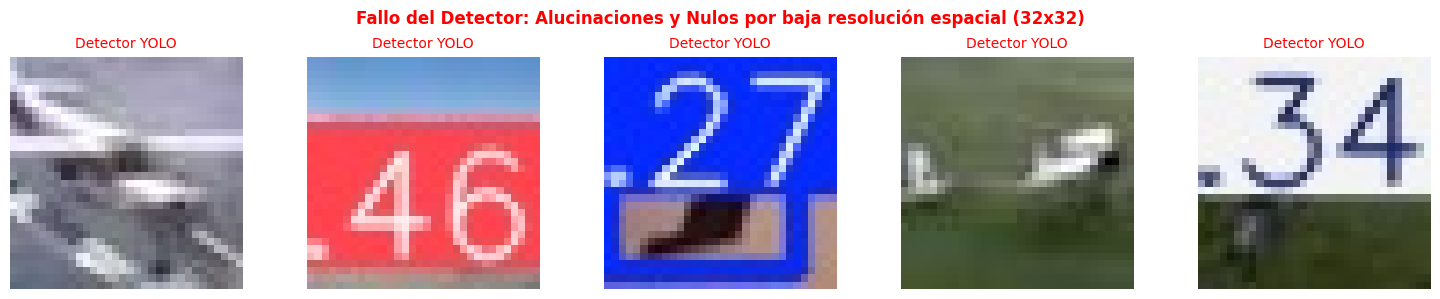


--- EXPERIMENTO 2: CLASIFICACIÓN (yolov8n-cls.pt) ---
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/cifar10_yolo_final, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=32, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_cifar10_cls2, nbs=64, nms=False, opset=None, optimize=

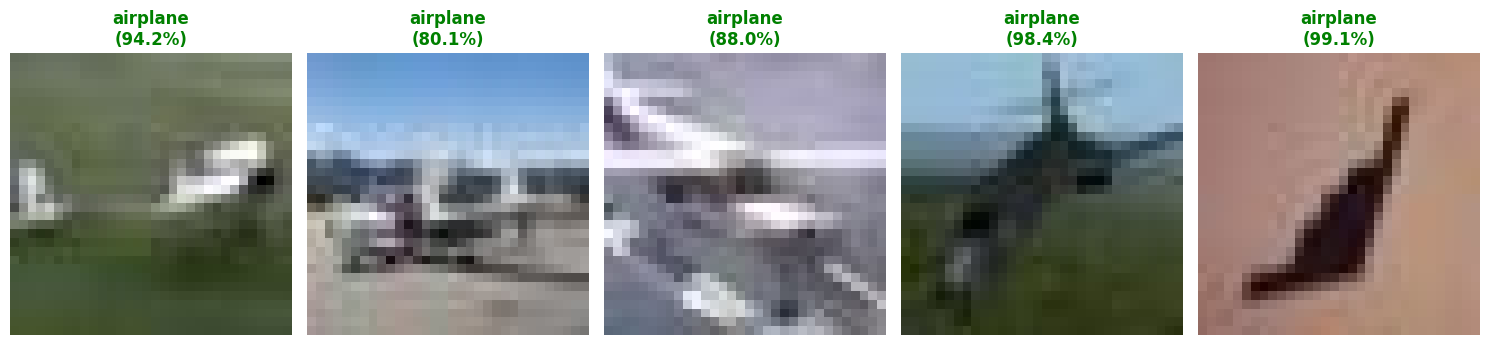


--- LIVE DEMO: Comparativa frente a imagen no vista de internet ---


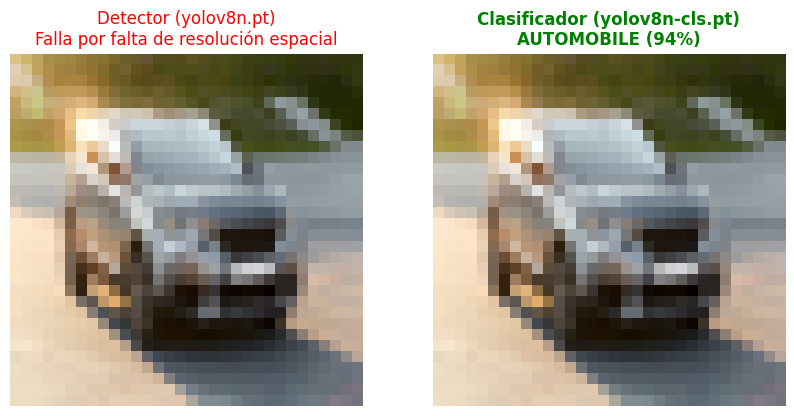

In [10]:
# =========================================================================
# 5. PROTOTIPADO AVANZADO CON YOLOv8 (Preparación y Experimentos)
# =========================================================================

print("--- FASE 1: PREPARANDO EL DATASET PARA YOLO ---")

# PASO 1: YOLO no entiende el formato de TensorFlow en memoria.
# Necesita que las fotos estén guardadas en carpetas reales en el disco duro.
base_path = "/content/cifar10_yolo_final"

# Creamos las carpetas principales (Train, Val, Test) si no existen
for split in ["train", "val", "test"]:
    os.makedirs(f"{base_path}/{split}", exist_ok=True)
print("1. Carpetas base creadas.")

# PASO 2: Volvemos a descargar CIFAR-10, pero esta vez todo junto para extraer las fotos físicas
dataset_yolo, info_yolo = tfds.load("cifar10", split="train+test", with_info=True)
class_names = info_yolo.features["label"].names

# Nos quedamos solo con los índices de los vehículos
vehiculos_idx = [0, 1, 8, 9]
vehicle_class_names = [class_names[i] for i in vehiculos_idx]

# PASO 3: Filtramos las fotos de vehículos y ajustamos sus etiquetas (0, 1, 2, 3)
filtered_data = []
for sample in dataset_yolo:
    original_label = sample["label"].numpy()
    if original_label in vehiculos_idx:
        if original_label == 0:   # airplane
            sample["label"] = tf.constant(0, dtype=tf.int64)
        elif original_label == 1: # automobile
            sample["label"] = tf.constant(1, dtype=tf.int64)
        elif original_label == 8: # ship
            sample["label"] = tf.constant(2, dtype=tf.int64)
        elif original_label == 9: # truck
            sample["label"] = tf.constant(3, dtype=tf.int64)
        filtered_data.append(sample)

# PASO 4: Barajamos las fotos y las dividimos en proporciones (70% Train, 20% Val, 10% Test)
all_data = list(filtered_data)
random.shuffle(all_data)

n = len(all_data)
train_cut = int(0.7 * n)
val_cut = int(0.9 * n)

train_data = all_data[:train_cut]
val_data   = all_data[train_cut:val_cut]
test_data  = all_data[val_cut:]

# PASO 5: Función para guardar las imágenes físicamente en sus carpetas
def save_split(split_name, data):
    for i, sample in tqdm(enumerate(data), total=len(data), desc=f"Guardando imágenes de {split_name}"):
        image = sample["image"].numpy()
        label = sample["label"].numpy()
        cls = vehicle_class_names[label] # Sacamos el nombre (ej. 'automobile')

        # Creamos la subcarpeta de la clase si no existe (ej. train/automobile)
        class_dir = f"{base_path}/{split_name}/{cls}"
        os.makedirs(class_dir, exist_ok=True)

        # Guardamos el array de números como una imagen real .jpg
        img = Image.fromarray(image)
        img_path = f"{class_dir}/{split_name}_{cls}_{i}.jpg"
        img.save(img_path)

# Ejecutamos el guardado
save_split("train", train_data)
save_split("val", val_data)
save_split("test", test_data)
print("2. Imágenes exportadas con éxito para YOLO.\n")


# -------------------------------------------------------------------------
# EXPERIMENTOS YOLO
# -------------------------------------------------------------------------

print("--- EXPERIMENTO 1: DETECCIÓN (yolov8n.pt) ---")
# Usamos el modelo pre-entrenado de detección (Cajas delimitadoras)
model_det = YOLO('yolov8n.pt')

# Cogemos 5 imágenes aleatorias de nuestra nueva carpeta de test
test_images_paths = glob.glob(f"{base_path}/test/*/*.jpg")[:5]

# Probamos el detector con confianza muy baja (0.1) para forzarle a que intente ver algo.
results_det = model_det.predict(source=test_images_paths, save=True, conf=0.1)

# YOLO guarda los resultados en una carpeta automática, buscamos la más reciente
latest_det_folder = max(glob.glob('runs/detect/predict*'), key=os.path.getmtime)

plt.figure(figsize=(15, 3))
saved_images = glob.glob(f"{latest_det_folder}/*.jpg")
for i, img_path in enumerate(saved_images[:5]):
    ax = plt.subplot(1, 5, i + 1)
    ax.imshow(mpimg.imread(img_path))
    ax.axis('off')
    ax.set_title("Detector YOLO", fontsize=10, color='red')
plt.suptitle("Fallo del Detector: Alucinaciones y Nulos por baja resolución espacial (32x32)", color='red', fontweight='bold')
plt.tight_layout()
plt.show()


print("\n--- EXPERIMENTO 2: CLASIFICACIÓN (yolov8n-cls.pt) ---")
# Al ver que la detección falla por el tamaño de la imagen, pivotamos a un modelo de clasificación
model_cls = YOLO("yolov8n-cls.pt")

# Entrenamos (Fine-tuning) sobre nuestras carpetas recién creadas
results_train = model_cls.train(data=base_path, epochs=5, imgsz=32, batch=32, name='yolo_cifar10_cls', verbose=False)

# --- VISUALIZACIÓN DE RESULTADOS DE CLASIFICACIÓN  ---
print("\n--- Visualización de resultados de clasificación ---")

# Hacemos la predicción pero NO guardamos la imagen (save=False). Queremos los datos numéricos.
results_cls_test = model_cls.predict(source=test_images_paths, save=False, verbose=False)

# Creamos el gráfico manual
plt.figure(figsize=(15, 6))

for i, (result, img_path) in enumerate(zip(results_cls_test, test_images_paths)):
    # A. Obtenemos los datos de la predicción
    top1_index = result.probs.top1
    nombre_predicho = result.names[top1_index]
    confianza = result.probs.top1conf.item()

    # B. Cargamos la imagen original limpia desde el disco
    img = mpimg.imread(img_path)

    # C. Pintamos
    ax = plt.subplot(1, 5, i + 1)
    ax.imshow(img)

    # D. Ponemos la "marca de agua" como título encima para que se lea bien
    titulo = f"{nombre_predicho}\n({confianza*100:.1f}%)"

    # Si acierta, título verde. Si falla, título rojo.
    etiqueta_real = img_path.split("/")[-2] # Sacamos el nombre real de la carpeta
    color = 'green' if nombre_predicho == etiqueta_real else 'red'

    ax.set_title(titulo, color=color, fontsize=12, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()


# -------------------------------------------------------------------------
# LIVE DEMO FINAL: COMPARATIVA
# -------------------------------------------------------------------------
print("\n--- LIVE DEMO: Comparativa frente a imagen no vista de internet ---")

# Descargamos una foto real de internet
url = "https://www.grupogil.es/wp-content/uploads/2024/09/img71-thegem-blog-default.jpg"
response = requests.get(url)
# La reducimos drásticamente a 32x32 para simular nuestro entorno
img = Image.open(BytesIO(response.content)).resize((32, 32))

# Pasamos la foto por ambos modelos
res_det = model_det.predict(img, conf=0.1, verbose=False)[0]
res_cls = model_cls.predict(img, verbose=False)[0]

# Extraemos la clase ganadora y su probabilidad del clasificador
clase_ganadora = res_cls.names[res_cls.probs.top1]
probabilidad = res_cls.probs.top1conf.item()

# Dibujamos el veredicto final
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(res_det.plot() if len(res_det.boxes) > 0 else img)
plt.title("Detector (yolov8n.pt)\nFalla por falta de resolución espacial", color='red')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img)
plt.title(f"Clasificador (yolov8n-cls.pt)\n{clase_ganadora.upper()} ({probabilidad*100:.0f}%)", color='green', fontweight='bold')
plt.axis('off')
plt.show()